# Differentiable Renderer Pipeline & Numerical Stability Test (10 DAP Cowpea)

This notebook tests the end-to-end differentiable renderer pipeline and its numerical stability when fitting a typed `PlantOrganArray` to a synthetic plant image.

### Refined Pipeline Stages:
1. **Ground Truth Data Generation**: Generate 10 DAP plant XML & Ground Truth using C++ Helios executable with `-n dap10_groundtruth`.
2. **Differentiable Target Rendering & Optimization**: Render ground truth XML into a target image ($I_{\text{target}}$) using `PlantOrganArray` and `HeliosPyTorchRenderer`. Initialize perturbed parameters ($N_{\text{param}} = N_{\text{gt}} + \text{noise}$), optimize via backprop against $I_{\text{target}}$, and monitor numerical stability (gradient norms, NaN/Inf tracking, parameter bounds, loss trajectory).
3. **C++ Helios Re-Rendering & Evaluation**: Export optimized `PlantOrganArray` back to XML (`dap10_rerendered.xml`), pass `'xml': 'dap10_rerendered.xml'` in `params.json`, re-render using C++ Helios executable with `-n dap10_rerendered`, and produce a 3-panel comparison figure ($I_{\text{target}}$ vs $I_{\text{pred}}$ vs $I_{\text{rerender}}$).

In [1]:
# Step 0: Environment Setup & Host Display Logic
import os
import sys
import time
import json
import socket
import tempfile
import subprocess
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

repo_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__))) if '__file__' in globals() else '/home/lion397/codes/image-to-l-system'
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from diffusion_based.models.plant_organ_array import PlantOrganArray
from diffusion_based.models.helios_pytorch_geometry import HeliosPlantGeometryBuilder
from diffusion_based.models.helios_pytorch_renderer import HeliosPyTorchRenderer
from diffusion_based.models.helios_xml_parser import HeliosXMLParser

# Requirement 1: Host Display check
env = os.environ.copy()
hostname = socket.gethostname()
if hostname.startswith("gpu-") or "gpu" in hostname or "DISPLAY" not in env:
    env["DISPLAY"] = ":1.0"
    print(f"[ENV] Host '{hostname}' -> export DISPLAY=:1.0")
else:
    print(f"[ENV] Host '{hostname}', DISPLAY={env.get('DISPLAY')}")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device:     {torch.cuda.get_device_name(0)}")

[ENV] Host 'gpu-10-50' -> export DISPLAY=:1.0
PyTorch version: 2.5.1+cu121
CUDA available:  True
CUDA Device:     NVIDIA RTX 6000 Ada Generation


---
## Stage 1: Generate 10 DAP Ground Truth Data using C++ Helios Executable (-n dap10_groundtruth)

We generate a 10 DAP plant XML and reference image using the C++ binary with unique output prefix `-n dap10_groundtruth`.

In [2]:
DAP = 10
SEED = 42
OUTPUT_DIR = os.path.join(repo_root, "notebooks", "output_dap10_stability")
os.makedirs(OUTPUT_DIR, exist_ok=True)

main_binary = os.path.join(repo_root, "Digital-Crops", "projects", "syntheticdata_generation", "build", "main")
base_params_file = os.path.join(repo_root, "Digital-Crops", "projects", "syntheticdata_generation", "params.json")

with open(base_params_file, "r") as f:
    params = json.load(f)

params.setdefault("camera", {}).setdefault("positioning", {})["azimuth_angle"] = 0.0
params["camera"]["positioning"]["camera_height"] = 1.0
params["camera"]["positioning"]["focusing_plants"] = True
params.setdefault("metadata", {})["dap"] = int(DAP)
params["metadata"].pop("DAP", None)

# Requirement 2: Unique ground truth output prefix
name = "dap10_groundtruth"
tmp_params_path = os.path.join(OUTPUT_DIR, f"{name}_params.json")
with open(tmp_params_path, "w") as f:
    json.dump(params, f, indent=2)

cmd = [
    main_binary,
    "--renderer", "vis",
    "--save-xml",
    "--focus-plant",
    "-n", name,
    "--dap", str(DAP),
    "-s", str(SEED),
    "--output", OUTPUT_DIR,
    "-f", tmp_params_path,
]

print(f"Executing C++ Helios binary: {' '.join(cmd)}")
t0 = time.time()
res = subprocess.run(cmd, cwd=os.path.dirname(main_binary), env=env, capture_output=True, text=True)
print(f"Completed in {time.time()-t0:.2f}s")

gt_xml_path = os.path.join(OUTPUT_DIR, f"{name}_0000_plant_0000.xml")
gt_img_path = os.path.join(OUTPUT_DIR, f"{name}_0000_vis.jpeg")
if not os.path.exists(gt_img_path):
    gt_img_path = os.path.join(OUTPUT_DIR, f"{name}_0000.jpeg")

print(f"Ground Truth XML: {gt_xml_path}")
print(f"Ground Truth Image: {gt_img_path}")

Executing C++ Helios binary: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/main --renderer vis --save-xml --focus-plant -n dap10_groundtruth --dap 10 -s 42 --output /home/lion397/codes/image-to-l-system/notebooks/output_dap10_stability -f /home/lion397/codes/image-to-l-system/notebooks/output_dap10_stability/dap10_groundtruth_params.json


Completed in 8.27s
Ground Truth XML: /home/lion397/codes/image-to-l-system/notebooks/output_dap10_stability/dap10_groundtruth_0000_plant_0000.xml
Ground Truth Image: /home/lion397/codes/image-to-l-system/notebooks/output_dap10_stability/dap10_groundtruth_0000_vis.jpeg


---
## Stage 2: Differentiable Target Render & PlantOrganArray Optimization

Following the stability test procedure:
1. Render the ground truth XML into a target image ($I_{\text{target}}$) using typed `PlantOrganArray` and `HeliosPyTorchRenderer`.
2. Perturb `PlantOrganArray` parameters ($N_{\text{param}} = N_{\text{gt}} + \text{noise}$).
3. Optimize $N_{\text{param}}$ via backpropagation against $I_{\text{target}}$ while tracking loss trajectory, gradient norms, NaN/Inf checks, and parameter convergence.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 256
NUM_ITERS = 200
LR = 0.005
NOISE_SCALE = 0.05

# Parse GT XML to typed PlantOrganArray
gt_organ_array = PlantOrganArray.from_xml_file_typed(gt_xml_path)
print(f"Parsed GT typed PlantOrganArray with {gt_organ_array.num_nodes} organ nodes (is_typed={gt_organ_array.is_typed}).")

renderer = HeliosPyTorchRenderer(image_size=IMAGE_SIZE)

# Requirement 3: Render target image using Differentiable Renderer
with torch.no_grad():
    target_rgb_tensor = renderer.render_organ_array(
        gt_organ_array,
        azimuth_deg=0.0,
        elevation_deg=90.0,
        camera_height=1.0,
        background="ground",
        device=device,
        focus_plant=True,
    )

target_rgb_np = target_rgb_tensor.permute(1, 2, 0).cpu().numpy().clip(0, 1)

# Add perturbation to initial organ array tensor
torch.manual_seed(42)
organ_array_param = PlantOrganArray.from_xml_file_typed(gt_xml_path)
param_tensor = organ_array_param.tensor.to(device).clone().detach()

# Perturb parameter values with noise
param_tensor = param_tensor + torch.randn_like(param_tensor) * NOISE_SCALE
param_tensor = param_tensor.detach().requires_grad_(True)
organ_array_param.tensor = param_tensor

gt_tensor = gt_organ_array.tensor.to(device)
optimizer = torch.optim.Adam([param_tensor], lr=LR)
history = {"loss": [], "loss_rgb": [], "grad_norm": [], "nan_count": 0, "inf_count": 0, "param_err": []}

print(f"Starting optimization against Differentiable Target Input for {NUM_ITERS} iterations...")
t0 = time.time()

for i in range(1, NUM_ITERS + 1):
    optimizer.zero_grad()
    
    organ_array_param.tensor = param_tensor
    pred_rgb_tensor = renderer.render_organ_array(
        organ_array_param,
        azimuth_deg=0.0,
        elevation_deg=90.0,
        camera_height=1.0,
        background="ground",
        device=device,
        focus_plant=True,
        differentiable=True,
    )
    
    loss_rgb = F.l1_loss(pred_rgb_tensor, target_rgb_tensor)
    loss = loss_rgb
    
    loss.backward()
    
    grad = param_tensor.grad
    if grad is not None:
        if torch.isnan(grad).any().item() or torch.isnan(pred_rgb_tensor).any().item():
            history["nan_count"] += 1
        if torch.isinf(grad).any().item() or torch.isinf(pred_rgb_tensor).any().item():
            history["inf_count"] += 1
        grad_norm = grad.norm().item()
    else:
        grad_norm = 0.0
        
    param_err = (param_tensor.detach() - gt_tensor).abs().mean().item()
    
    history["loss"].append(loss.item())
    history["loss_rgb"].append(loss_rgb.item())
    history["grad_norm"].append(grad_norm)
    history["param_err"].append(param_err)
    
    optimizer.step()
    
    if i == 1 or i % 50 == 0 or i == NUM_ITERS:
        print(f"Iter {i:03d}/{NUM_ITERS:03d} | Loss: {loss.item():.5f} | GradNorm: {grad_norm:.4f} | ParamErr: {param_err:.5f}")

print(f"Optimization done in {time.time()-t0:.2f}s | NaNs: {history['nan_count']} | Infs: {history['inf_count']}")

Parsed GT typed PlantOrganArray with 94 organ nodes (is_typed=True).


Starting optimization against Differentiable Target Input for 200 iterations...
Iter 001/200 | Loss: 0.08922 | GradNorm: 0.0211 | ParamErr: 0.03943


Iter 050/200 | Loss: 0.14432 | GradNorm: 0.0433 | ParamErr: 0.04106


Iter 100/200 | Loss: 0.09993 | GradNorm: 0.0177 | ParamErr: 0.04258


Iter 150/200 | Loss: 0.14654 | GradNorm: 0.0143 | ParamErr: 0.04301


Iter 200/200 | Loss: 0.10731 | GradNorm: 0.0275 | ParamErr: 0.04332
Optimization done in 14.67s | NaNs: 0 | Infs: 0


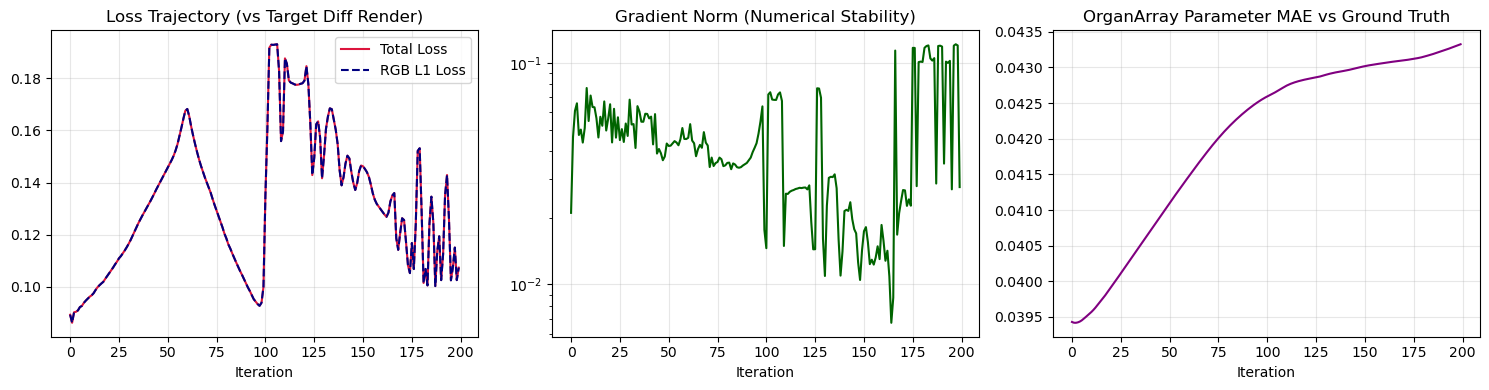

In [4]:
# Plot Optimization Diagnostics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["loss"], label="Total Loss", color="crimson")
axes[0].plot(history["loss_rgb"], label="RGB L1 Loss", color="navy", linestyle="--")
axes[0].set_title("Loss Trajectory (vs Target Diff Render)")
axes[0].set_xlabel("Iteration")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history["grad_norm"], color="darkgreen")
axes[1].set_title("Gradient Norm (Numerical Stability)")
axes[1].set_xlabel("Iteration")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

axes[2].plot(history["param_err"], color="purple")
axes[2].set_title("OrganArray Parameter MAE vs Ground Truth")
axes[2].set_xlabel("Iteration")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Stage 3: Re-rendering Optimized XML via C++ Helios Executable (-n dap10_rerendered)

We reconstruct the Helios plant XML from the optimized `PlantOrganArray` (`dap10_rerendered.xml`), pass `'xml': 'dap10_rerendered.xml'` in `params.json`, re-render using C++ Helios binary with `-n dap10_rerendered`, and display the 3-panel comparison figure.

Optimized XML written to: /home/lion397/codes/image-to-l-system/notebooks/output_dap10_stability/dap10_rerendered.xml


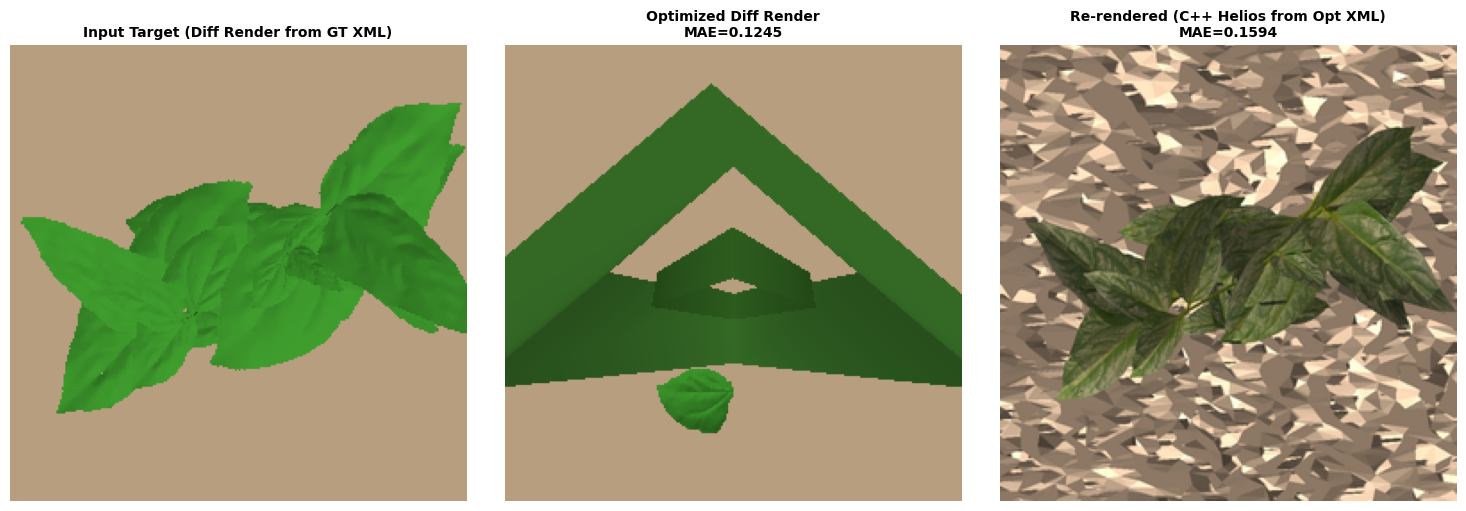

In [5]:
# Save optimized PlantOrganArray to XML
opt_xml_path = os.path.abspath(os.path.join(OUTPUT_DIR, "dap10_rerendered.xml"))
organ_array_param.write_xml(opt_xml_path)
print(f"Optimized XML written to: {opt_xml_path}")

# Update params.json to point to optimized XML file
with open(base_params_file, "r") as f:
    rerender_params = json.load(f)

rerender_params.setdefault("camera", {}).setdefault("positioning", {})["azimuth_angle"] = 0.0
rerender_params["camera"]["positioning"]["camera_height"] = 1.0
rerender_params["camera"]["positioning"]["focusing_plants"] = True
rerender_params.setdefault("metadata", {})["dap"] = int(DAP)
rerender_params["field"]["plots"][0]["plants"][0]["xml"] = opt_xml_path

rerender_name = "dap10_rerendered"
tmp_params_path = os.path.join(OUTPUT_DIR, f"{rerender_name}_params.json")
with open(tmp_params_path, "w") as f:
    json.dump(rerender_params, f, indent=2)

cmd = [
    main_binary,
    "--renderer", "vis",
    "--focus-plant",
    "-n", rerender_name,
    "--dap", str(DAP),
    "-s", str(SEED),
    "--output", OUTPUT_DIR,
    "-f", tmp_params_path,
]

subprocess.run(cmd, cwd=os.path.dirname(main_binary), env=env, capture_output=True, text=True)
rerender_img_path = os.path.join(OUTPUT_DIR, f"{rerender_name}_0000_vis.jpeg")
if not os.path.exists(rerender_img_path):
    rerender_img_path = os.path.join(OUTPUT_DIR, f"{rerender_name}_0000.jpeg")

# Load final renders
with torch.no_grad():
    opt_pred_rgb_t = renderer.render_organ_array(
        organ_array_param,
        azimuth_deg=0.0,
        elevation_deg=90.0,
        camera_height=1.0,
        background="ground",
        device=device,
        focus_plant=True,
    )
opt_pred_rgb = opt_pred_rgb_t.permute(1, 2, 0).cpu().numpy().clip(0, 1)

rerender_pil = Image.open(rerender_img_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
rerender_rgb = np.array(rerender_pil, dtype=np.float32) / 255.0

# Compute metrics vs Differentiable Target Input
mae_pred = float(np.mean(np.abs(opt_pred_rgb - target_rgb_np)))
mae_rerender = float(np.mean(np.abs(rerender_rgb - target_rgb_np)))

# 3-Panel comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(target_rgb_np)
axes[0].set_title("Input Target (Diff Render from GT XML)", fontsize=10, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(opt_pred_rgb)
axes[1].set_title(f"Optimized Diff Render\nMAE={mae_pred:.4f}", fontsize=10, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(rerender_rgb)
axes[2].set_title(f"Re-rendered (C++ Helios from Opt XML)\nMAE={mae_rerender:.4f}", fontsize=10, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()